In [9]:
from notebook_setup import setup_notebook_environment

PROJECT_ROOT, SIMULATION_PATH = setup_notebook_environment()

In [10]:
SIMULATION_PATH

PosixPath('/Users/scmps8/repos/github.com/microtorch/simulation_data')

In [11]:
import os

#define the path to the simulation data
DATA_PATH = os.path.join(SIMULATION_PATH,"data")

#define the path to the fit output directory
OUTPUT_PATH = os.path.join(PROJECT_ROOT,"outputs")

#find the models where simulation data exists
simulation_data_models = [f for f in os.listdir(DATA_PATH) if not f.startswith(".")]


In [12]:
from src.utils.most_recent_output_file import most_recent_output_file

most_recent_output_file(OUTPUT_PATH, "VERDICT")

PosixPath('/Users/scmps8/repos/github.com/microtorch/outputs/2026-03-03/14-25-20/VERDICT_BallSphereAstrosticks_data_param_maps.nii.gz')

In [13]:
import glob
import nibabel as nib
from src.utils.most_recent_output_file import most_recent_output_file
import torch

sim_data = {}

for model in simulation_data_models:    
    #get the simulated data, ground truth parameters and mask for each model and store in a dictionary
    sim_data[model + "_data"] = torch.from_numpy(nib.load(glob.glob(os.path.join(DATA_PATH, model, "*_data.nii.gz"))[0]).get_fdata())
    sim_data[model + "_gt_params"] = torch.from_numpy(nib.load(glob.glob(os.path.join(DATA_PATH, model, "*_params.nii.gz"))[0]).get_fdata())
    sim_data[model + "_mask"] = torch.from_numpy(nib.load(glob.glob(os.path.join(DATA_PATH, model, "*_mask.nii.gz"))[0]).get_fdata())
    
    #get the fitted parameters for each model and store in the dictionary
    try:
        sim_data[model + "_fitted_params"] = torch.from_numpy(nib.load(most_recent_output_file(OUTPUT_PATH, model)).get_fdata())
        print(f"Fitted parameters found and loaded for model {model}.")
    except:
        print(f"No fitted parameters found for model {model}. Skipping.")       
        simulation_data_models = [m for m in simulation_data_models if m != model]  #remove the model from the list of models 
    
    
    
    

Fitted parameters found and loaded for model Zeppelin.
Fitted parameters found and loaded for model Astrosticks.
Fitted parameters found and loaded for model ZeppelinZeppelin.
Fitted parameters found and loaded for model Stick.
Fitted parameters found and loaded for model SANDI.
Fitted parameters found and loaded for model Msdki.
Fitted parameters found and loaded for model Sphere.
Fitted parameters found and loaded for model VERDICT.
Fitted parameters found and loaded for model Ball.
Fitted parameters found and loaded for model IVIM.
Fitted parameters found and loaded for model BallStick.


In [14]:
#flatten the images

from src.utils.preprocessing import img2voxel

for model in simulation_data_models:
    sim_data[model + "_gt_params_flat"], sim_data[model + "_mask_flat"]= img2voxel(sim_data[model + "_gt_params"], sim_data[model + "_mask"])
    sim_data[model + "_fitted_params_flat"], sim_data[model + "_mask_flat"] = img2voxel(sim_data[model + "_fitted_params"], sim_data[model + "_mask"])

########### (<src.signal_models.gaussian_models.Zeppelin object at 0x1175a53a0>,)


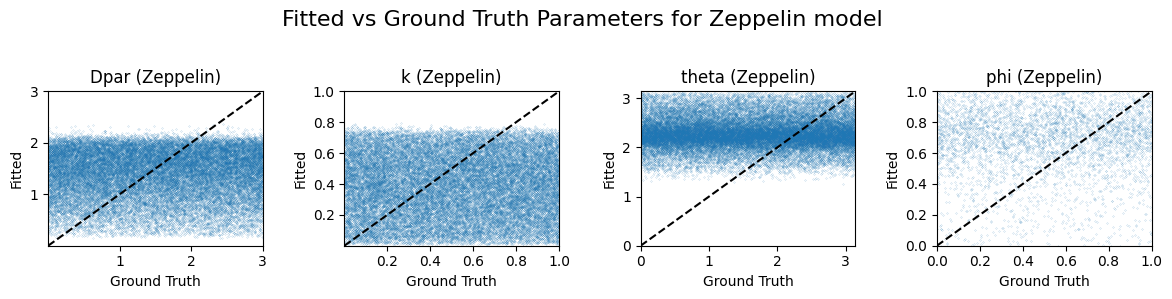

########### (<src.signal_models.cylinder_models.Astrosticks object at 0x117970380>,)


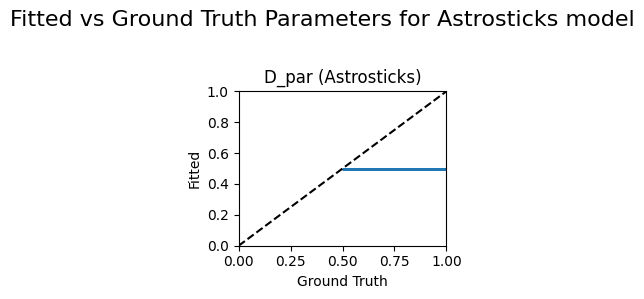

########### (<src.signal_models.gaussian_models.Zeppelin object at 0x1176a76b0>, <src.signal_models.gaussian_models.Zeppelin object at 0x11724a870>)


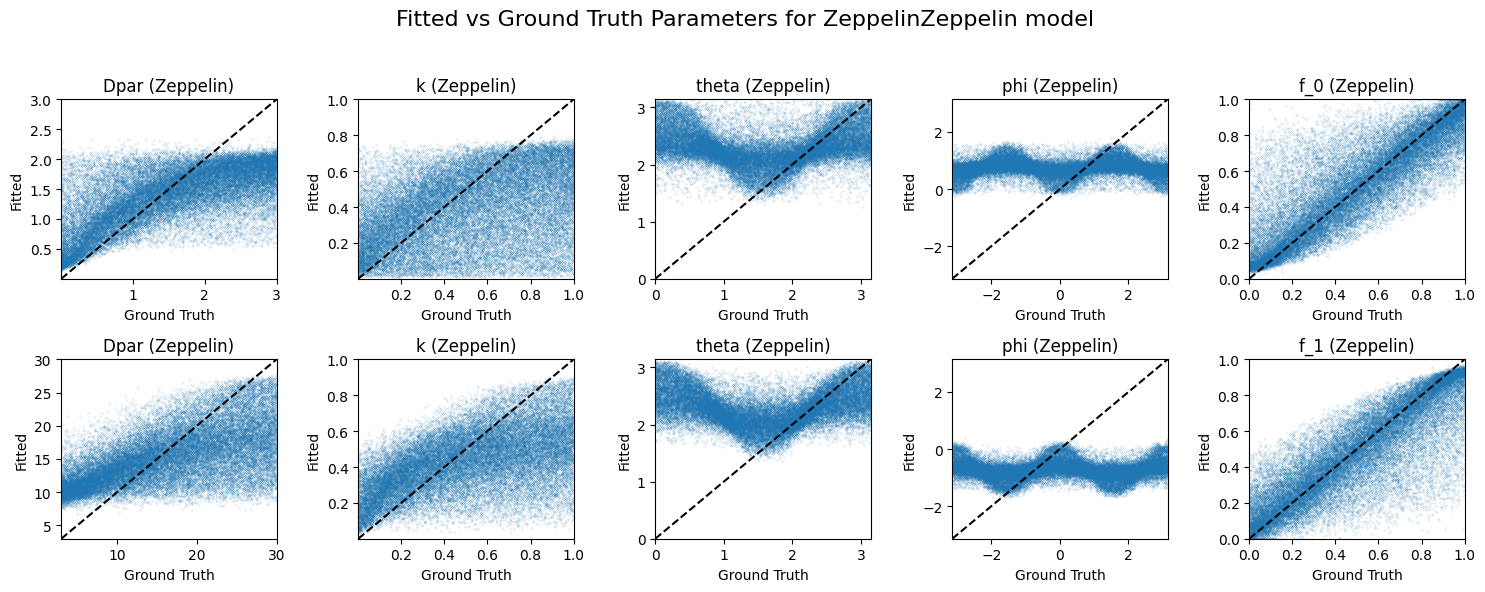

########### (<src.signal_models.cylinder_models.Stick object at 0x1174fe990>,)


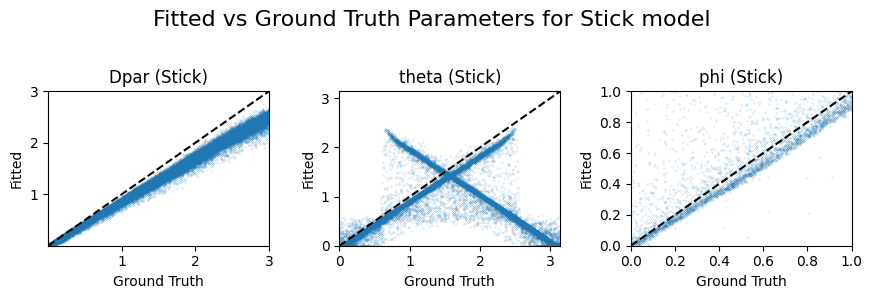

########### (<src.signal_models.gaussian_models.Ball object at 0x1174ce4b0>, <src.signal_models.sphere_models.Sphere object at 0x117970c50>, <src.signal_models.cylinder_models.Astrosticks object at 0x117169580>)


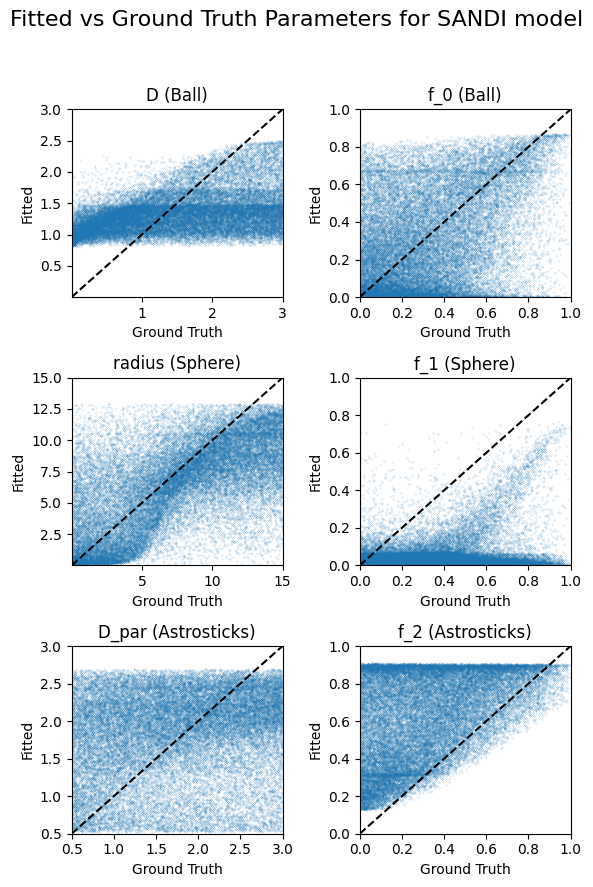

########### (<src.signal_models.gaussian_models.Msdki object at 0x117f3ad80>,)


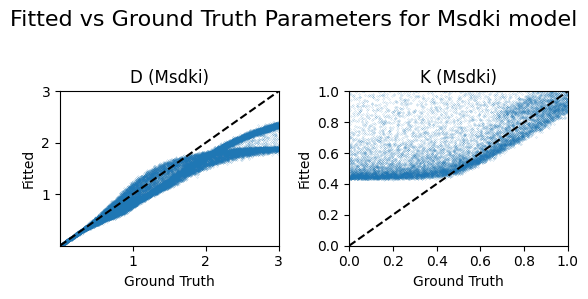

########### (<src.signal_models.sphere_models.Sphere object at 0x11713ce60>,)


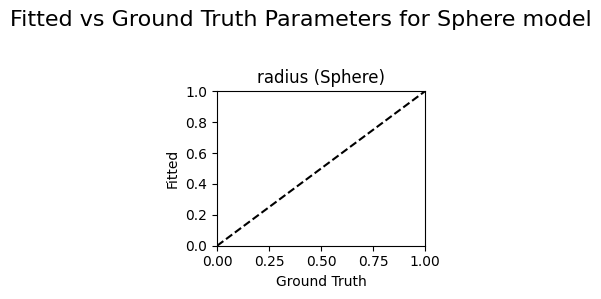

########### (<src.signal_models.gaussian_models.Ball object at 0x11716a570>, <src.signal_models.sphere_models.Sphere object at 0x11716bb60>, <src.signal_models.cylinder_models.Astrosticks object at 0x11701aa50>)


/var/folders/zl/mns1flqj7bjgsvh9mz33sk2h0000gp/T/ipykernel_49190/1431532428.py:57: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  axis.set_xlim(pr)
/var/folders/zl/mns1flqj7bjgsvh9mz33sk2h0000gp/T/ipykernel_49190/1431532428.py:58: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axis.set_ylim(pr)


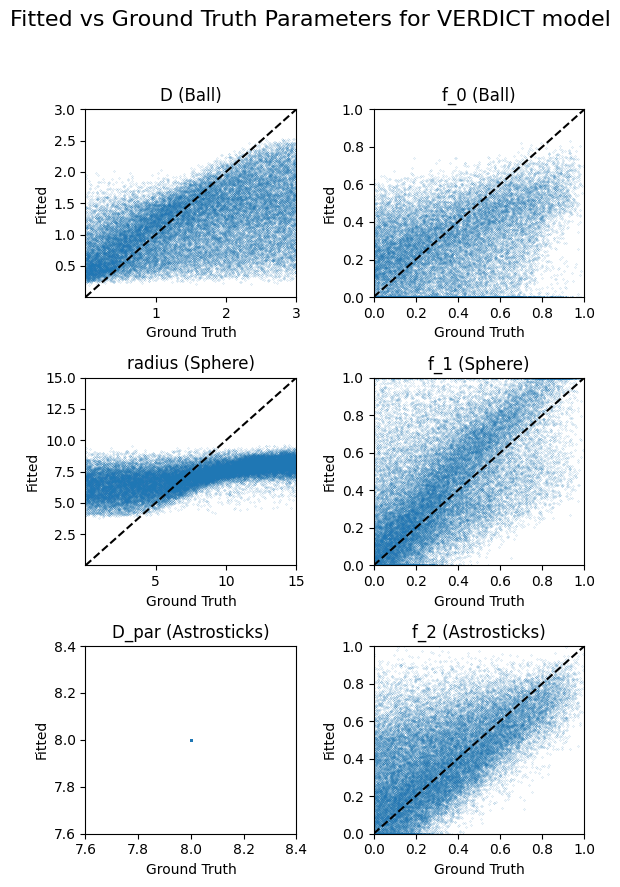

########### (<src.signal_models.gaussian_models.Ball object at 0x117018c80>,)


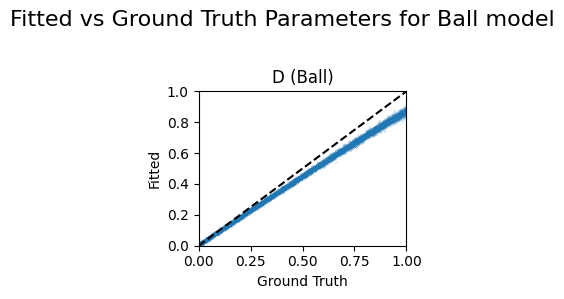

########### (<src.signal_models.gaussian_models.Ball object at 0x11702e840>, <src.signal_models.gaussian_models.Ball object at 0x1174aa630>)


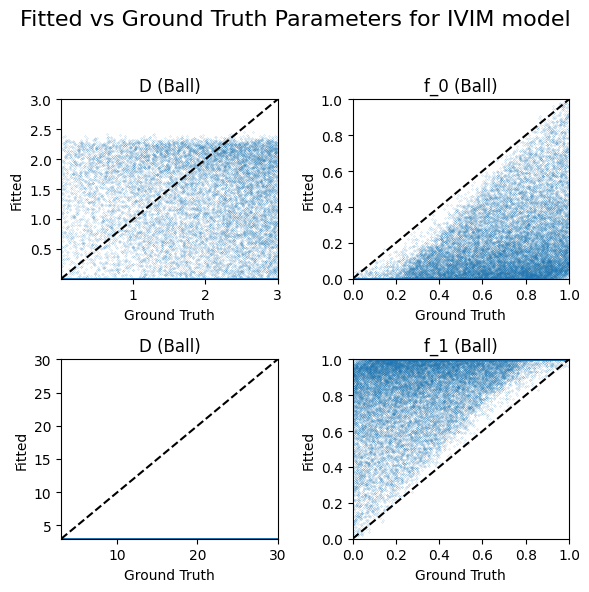

########### (<src.signal_models.gaussian_models.Ball object at 0x1180150d0>, <src.signal_models.cylinder_models.Stick object at 0x117971f70>)


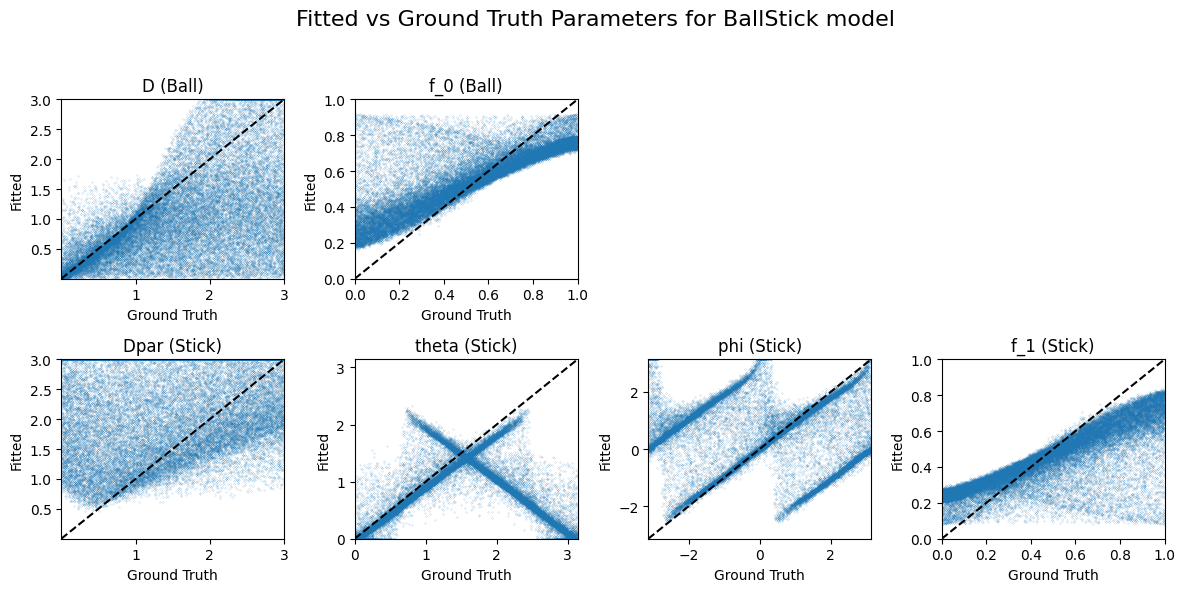

In [15]:
import matplotlib.pyplot as plt
import numpy as np

from src.model_maker import ModelMaker

for model in simulation_data_models:

    modelfunc = ModelMaker(model)

    gt = sim_data[model + "_gt_params_flat"]
    fit = sim_data[model + "_fitted_params_flat"]

    n_maps = gt.shape[1]

    n_compartments = modelfunc.n_fractions

    #count how many params belong to each compartment 
    comp_param_counts = [
        sum(1 for p in range(n_maps) if modelfunc.compartment_indices[p] == c)
        for c in range(n_compartments)
    ]
    max_params = max(comp_param_counts) if comp_param_counts else 1

    fig, ax = plt.subplots(
        n_compartments, max_params,
        figsize=(3 * max_params, 3 * n_compartments),
        squeeze=False
    )

    # plot each compartment row
    for c in range(n_compartments):
        # parameter indices for this compartment (preserves original order)
        p_idxs = [p for p in range(n_maps) if modelfunc.compartment_indices[p] == c]

        for j in range(max_params):
            axis = ax[c, j]

            if j >= len(p_idxs):
                axis.axis("off")
                continue

            p = p_idxs[j]

            axis.plot(gt[:, p], fit[:, p], "o", markersize=0.1)

            axis.set_title(
                f"{modelfunc.parameter_names[p]} "
                f"({modelfunc.compartment_names[modelfunc.compartment_indices[p]]})"
            )
            axis.set_xlabel("Ground Truth")
            axis.set_ylabel("Fitted")

            # --- identity line + limits ---
            if p < (n_maps - modelfunc.n_fractions):  # non-fraction parameters
                pr = modelfunc.parameter_ranges[p]
                axis.plot(pr, pr, "k--")
                axis.set_xlim(pr)
                axis.set_ylim(pr)
            else:  # fraction parameters
                axis.plot([0, 1], [0, 1], "k--")
                axis.set_xlim(0, 1)
                axis.set_ylim(0, 1)

    plt.suptitle(f"Fitted vs Ground Truth Parameters for {model} model", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

########### (<src.signal_models.gaussian_models.Zeppelin object at 0x117902150>,)


IndexError: index 4 is out of bounds for dimension 1 with size 4

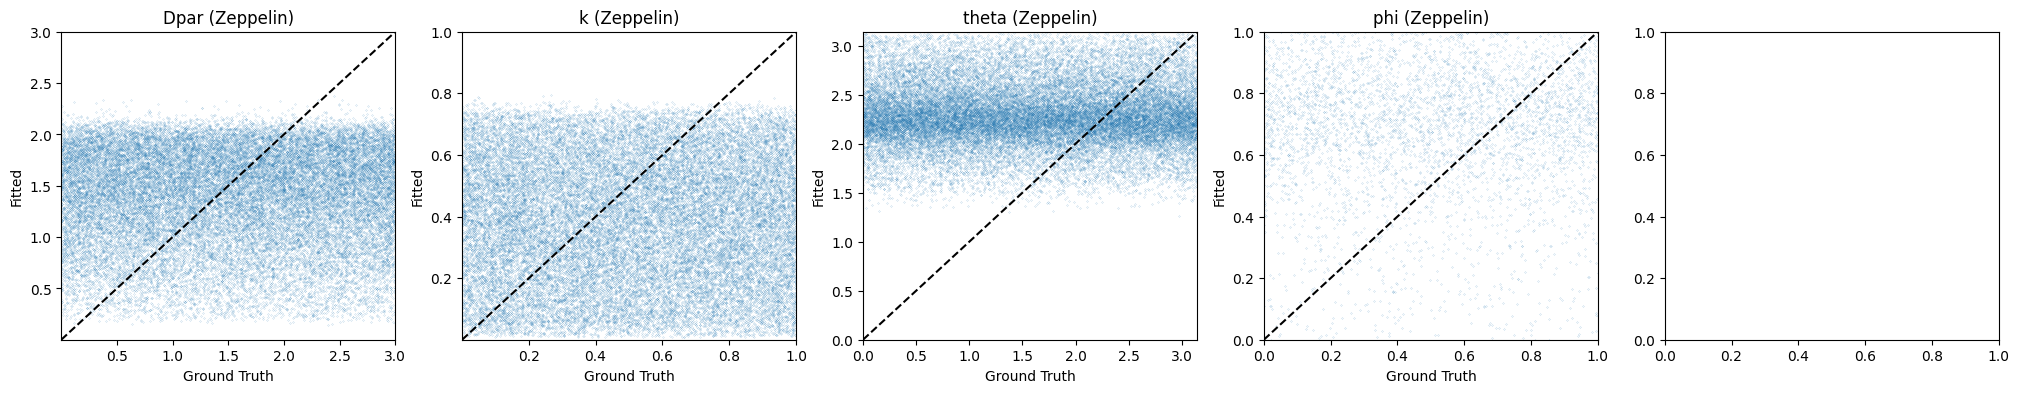

In [16]:
import matplotlib.pyplot as plt
import numpy as np

from src.model_maker import ModelMaker

for model in simulation_data_models:

    modelfunc = ModelMaker(model)

    gt = sim_data[model + "_gt_params_flat"]
    fitted = sim_data[model + "_fitted_params_flat"]

    n_maps = gt.shape[1]

    # --- group parameters by compartment ---
    comp_indices = modelfunc.compartment_indices
    n_compartments = len(modelfunc.compartment_names)

    # Collect parameter indices per compartment
    comp_to_params = {c: [] for c in range(n_compartments)}
    for p_idx, c_idx in enumerate(comp_indices):
        comp_to_params[c_idx].append(p_idx)

    max_cols = max(len(v) for v in comp_to_params.values())

    fig, ax = plt.subplots(
        n_compartments,
        max_cols,
        figsize=(5 * max_cols, 4 * n_compartments),
        squeeze=False
    )

    for c_idx in range(n_compartments):
        for col_idx in range(max_cols):

            axis = ax[c_idx, col_idx]

            # If this compartment has no parameter for this column, hide axis
            if col_idx >= len(comp_to_params[c_idx]):
                axis.axis("off")
                continue

            p_idx = comp_to_params[c_idx][col_idx]

            axis.plot(
                gt[:, p_idx],
                fitted[:, p_idx],
                "o",
                markersize=0.1
            )

            axis.set_title(
                f"{modelfunc.parameter_names[p_idx]} "
                f"({modelfunc.compartment_names[c_idx]})"
            )

            axis.set_xlabel("Ground Truth")
            axis.set_ylabel("Fitted")

            # --- limits + identity line ---
            if p_idx < n_maps - modelfunc.n_fractions:
                pr = modelfunc.parameter_ranges[p_idx]
                axis.plot(pr, pr, "k--")
                axis.set_xlim(pr)
                axis.set_ylim(pr)
            else:
                axis.plot([0, 1], [0, 1], "k--")
                axis.set_xlim(0, 1)
                axis.set_ylim(0, 1)

    plt.suptitle(
        f"Fitted vs Ground Truth Parameters for {model} model",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()